# Machine Learning Experiment Number 3

Name: Parth Shantaram Korgaonkar
Roll No.: Cs26
Batch: Cs-2

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv('/content/cardekho_dataset (1).csv')

# Display first 5 records
print("First 5 records:")
display(df.head())

# Dataset size
print("\nNumber of rows and columns:")
print(df.shape)

# Column names
print("\nColumn names:")
print(df.columns.tolist())

# Numerical attributes
numerical_attributes = df.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

# Categorical attributes
categorical_attributes = df.select_dtypes(
    include=['object']
).columns.tolist()

print("\nNumerical attributes:")
print(numerical_attributes)

print("\nCategorical attributes:")
print(categorical_attributes)

# Target variable
y = df['selling_price']

print("\nTarget variable:")
print("selling_price")

print("\nTarget variable shape:")
print(y.shape)

First 5 records:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000



Number of rows and columns:
(15411, 14)

Column names:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Numerical attributes:
['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Categorical attributes:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

Target variable:
selling_price

Target variable shape:
(15411,)


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [ ]:
# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:")
print(df.isnull().sum().sum())

# Handle missing values if any
if df.isnull().sum().sum() > 0:
    print("\nMissing values found. Removing rows containing missing values.")
    df = df.dropna().reset_index(drop=True)
else:
    print("\nNo missing values found.")

Missing values in each column:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values:
0

No missing values found.


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [ ]:
# Remove unnecessary index column
data = df.drop(columns=['Unnamed: 0']).copy()

# Target variable
target = 'selling_price'

# Features selected for the model
features = [
    'vehicle_age',
    'km_driven',
    'seller_type',
    'fuel_type',
    'transmission_type',
    'mileage',
    'engine',
    'max_power',
    'seats'
]

print("Selected Features:")
print(features)

print("\nTarget Variable:")
print(target)


Selected Features:
['vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats']

Target Variable:
selling_price


## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [ ]:
# Categorical columns
categorical_columns = [
    'seller_type',
    'fuel_type',
    'transmission_type'
]

# One-hot encoding
data_encoded = pd.get_dummies(
    data[features],
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("Dataset after encoding:")
display(data_encoded.head())

print("\nNew columns:")
print(data_encoded.columns.tolist())

print("\nData types:")
print(data_encoded.dtypes)

Dataset after encoding:


,vehicle_age,km_driven,mileage,engine,max_power,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,1,0,0,0,0,1,1
1,5,20000,18.90,1197,82.00,5,1,0,0,0,0,1,1
2,11,60000,17.00,1197,80.00,5,1,0,0,0,0,1,1
3,9,37000,20.92,998,67.10,5,1,0,0,0,0,1,1
4,6,30000,22.77,1498,98.59,5,0,0,1,0,0,0,1



New columns:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol', 'transmission_type_Manual']

Data types:
vehicle_age                       int64
km_driven                         int64
mileage                         float64
engine                            int64
max_power                       float64
seats                             int64
seller_type_Individual            int64
seller_type_Trustmark Dealer      int64
fuel_type_Diesel                  int64
fuel_type_Electric                int64
fuel_type_LPG                     int64
fuel_type_Petrol                  int64
transmission_type_Manual          int64
dtype: object


## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [ ]:
# The dataset already provides vehicle_age.
# We will use it as the car-age feature.

print("Vehicle age examples:")
display(data[['vehicle_age']].head(10))

print("\nVehicle age statistics:")
print(data['vehicle_age'].describe())

Vehicle age examples:


,vehicle_age
0,9
1,5
2,11
3,9
4,6
5,8
6,8
7,3
8,2
9,4



Vehicle age statistics:
count    15411.000000
mean         6.036338
std          3.013291
min          0.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         29.000000
Name: vehicle_age, dtype: float64


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

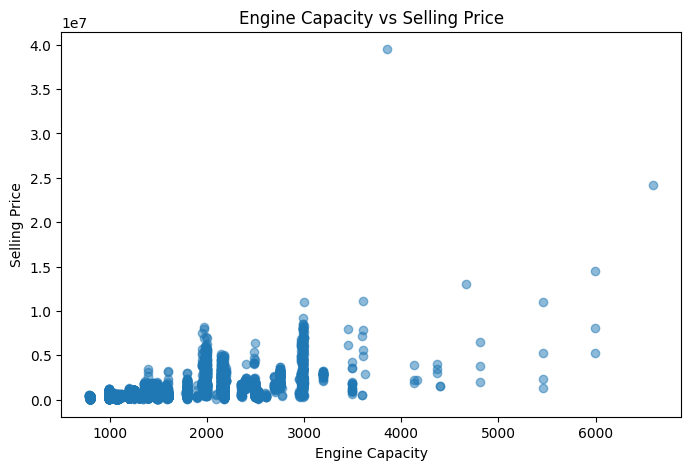

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    data['engine'],
    data['selling_price'],
    alpha=0.5
)

plt.xlabel('Engine Capacity')
plt.ylabel('Selling Price')
plt.title('Engine Capacity vs Selling Price')

plt.show()

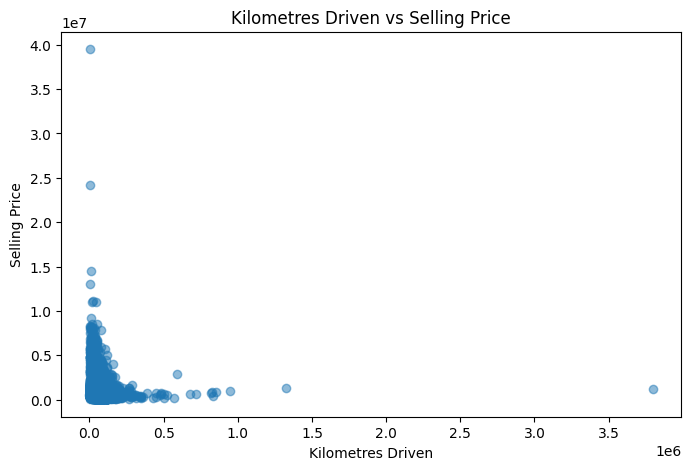

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    data['km_driven'],
    data['selling_price'],
    alpha=0.5
)

plt.xlabel('Kilometres Driven')
plt.ylabel('Selling Price')
plt.title('Kilometres Driven vs Selling Price')

plt.show()

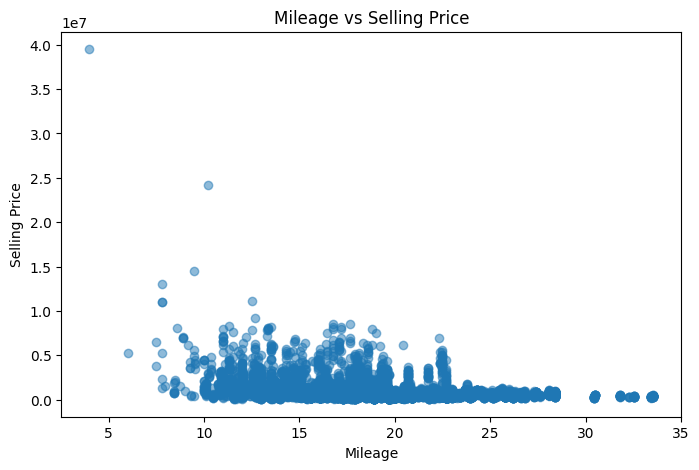

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    data['mileage'],
    data['selling_price'],
    alpha=0.5
)

plt.xlabel('Mileage')
plt.ylabel('Selling Price')
plt.title('Mileage vs Selling Price')

plt.show()

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [ ]:
# Separate X and y
X = data_encoded.copy()
y = data['selling_price'].values

print("X shape:", X.shape)
print("y shape:", y.shape)

# ------------------------------------------------
# 80:20 Train-Test Split
# ------------------------------------------------

np.random.seed(42)

# Randomly shuffle indices
indices = np.random.permutation(len(X))

train_size = int(0.80 * len(X))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

# Create training and testing sets
X_train_df = X.iloc[train_indices].copy()
X_test_df = X.iloc[test_indices].copy()

y_train = y[train_indices]
y_test = y[test_indices]

print("\nTraining observations:", len(X_train_df))
print("Testing observations:", len(X_test_df))

print("\nX_train shape:", X_train_df.shape)
print("X_test shape:", X_test_df.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X shape: (15411, 13)
y shape: (15411,)

Training observations: 12328
Testing observations: 3083

X_train shape: (12328, 13)
X_test shape: (3083, 13)
y_train shape: (12328,)
y_test shape: (3083,)


## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [ ]:
# TASK 9: Split the Dataset

# Set random seed for reproducibility
np.random.seed(42)

# Shuffle the data
indices = np.random.permutation(len(data_encoded))

# Calculate 80% training size
train_size = int(0.80 * len(data_encoded))

# Create training and testing indices
train_indices = indices[:train_size]
test_indices = indices[train_size:]

# Create training and testing datasets
X_train_df = data_encoded.iloc[train_indices].copy()
X_test_df = data_encoded.iloc[test_indices].copy()

y_train = data['selling_price'].iloc[train_indices].values
y_test = data['selling_price'].iloc[test_indices].values

# Display sizes
print("Training observations:", len(X_train_df))
print("Testing observations:", len(X_test_df))

print("\nTraining data shape:", X_train_df.shape)
print("Testing data shape:", X_test_df.shape)

Training observations: 12328
Testing observations: 3083

Training data shape: (12328, 13)
Testing data shape: (3083, 13)


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [ ]:
# TASK 10: Construct the Feature Matrix

# Convert training and testing DataFrames to NumPy arrays
X_train = X_train_df.values.astype(float)
X_test = X_test_df.values.astype(float)

# Target vectors
y_train = np.asarray(y_train, dtype=float)
y_test = np.asarray(y_test, dtype=float)

# Display shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (12328, 13)
y_train shape: (12328,)
X_test shape: (3083, 13)
y_test shape: (3083,)


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [ ]:
# TASK 11: Add Bias / Intercept Term

# Add a column of 1s for the intercept
X_train_bias = np.column_stack([
    np.ones(X_train.shape[0]),
    X_train
])

X_test_bias = np.column_stack([
    np.ones(X_test.shape[0]),
    X_test
])

print("X_train_bias shape:", X_train_bias.shape)
print("X_test_bias shape:", X_test_bias.shape)

print("\nFirst row of X_train_bias:")
print(X_train_bias[0])

X_train_bias shape: (12328, 14)
X_test_bias shape: (3083, 14)

First row of X_train_bias:
[1.000e+00 1.200e+01 7.300e+04 2.036e+01 1.197e+03 7.890e+01 5.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 1.000e+00 1.000e+00]


## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [ ]:
# TASK 12: Implement Ordinary Least Squares (OLS)

def ols(X, y):
    # Transpose of X
    X_T = X.T

    # Calculate X^T X
    XTX = X_T @ X

    # Calculate X^T y
    XTy = X_T @ y

    # Calculate inverse of X^T X
    XTX_inverse = np.linalg.inv(XTX)

    # Calculate regression coefficients
    beta = XTX_inverse @ XTy

    return beta


# Train the model
beta = ols(X_train_bias, y_train)

print("Regression coefficient vector:")
print(beta)

Regression coefficient vector:
[-5.72131766e+05 -6.46503603e+04 -6.41902210e-01  1.49539380e+04
  9.26568502e+01  1.50742603e+04  8.41455334e+03 -6.78355536e+03
 -7.80026728e+04 -1.24692430e+05 -9.67564105e+04  3.58735638e+05
 -1.19859216e+05 -1.21450230e+05]


## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [ ]:
# TASK 13: Check Matrix Singularity

# Calculate X^T X
XTX = X_train_bias.T @ X_train_bias

# Calculate determinant
determinant = np.linalg.det(XTX)

print("Determinant of X^T X:")
print(determinant)

if np.isclose(determinant, 0):
    print("\nWarning: X^T X is singular or nearly singular.")
else:
    print("\nX^T X is invertible.")

Determinant of X^T X:
6.100259541392836e+63

X^T X is invertible.


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [ ]:
# TASK 14: Train the Regression Model

# Feature names
feature_names = ['Intercept'] + X_train_df.columns.tolist()

print("Regression Coefficients:\n")

for name, coefficient in zip(feature_names, beta):
    print(f"{name}: {coefficient:.6f}")

Regression Coefficients:

Intercept: -572131.765613
vehicle_age: -64650.360329
km_driven: -0.641902
mileage: 14953.937955
engine: 92.656850
max_power: 15074.260335
seats: 8414.553338
seller_type_Individual: -6783.555363
seller_type_Trustmark Dealer: -78002.672818
fuel_type_Diesel: -124692.429562
fuel_type_Electric: -96756.410532
fuel_type_LPG: 358735.637965
fuel_type_Petrol: -119859.215609
transmission_type_Manual: -121450.230376


## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [ ]:
# TASK 15: Interpret Regression Coefficients

print("Coefficient Interpretation:\n")

for name, coefficient in zip(feature_names, beta):

    if name == 'Intercept':
        print(f"{name}: {coefficient:.4f}")

    elif coefficient > 0:
        print(f"{name}: Positive influence ({coefficient:.4f})")

    else:
        print(f"{name}: Negative influence ({coefficient:.4f})")

Coefficient Interpretation:

Intercept: -572131.7656
vehicle_age: Negative influence (-64650.3603)
km_driven: Negative influence (-0.6419)
mileage: Positive influence (14953.9380)
engine: Positive influence (92.6569)
max_power: Positive influence (15074.2603)
seats: Positive influence (8414.5533)
seller_type_Individual: Negative influence (-6783.5554)
seller_type_Trustmark Dealer: Negative influence (-78002.6728)
fuel_type_Diesel: Negative influence (-124692.4296)
fuel_type_Electric: Negative influence (-96756.4105)
fuel_type_LPG: Positive influence (358735.6380)
fuel_type_Petrol: Negative influence (-119859.2156)
transmission_type_Manual: Negative influence (-121450.2304)


## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [ ]:
# TASK 16: Predict Selling Prices

# Calculate predicted selling prices
y_pred = X_test_bias @ beta

# Create comparison table
comparison = pd.DataFrame({
    'Actual Selling Price': y_test,
    'Predicted Selling Price': y_pred
})

print("Actual vs Predicted Selling Prices:")
display(comparison.head(10))

Actual vs Predicted Selling Prices:


,Actual Selling Price,Predicted Selling Price
0,4450000.0,2.046440e+06
1,1290000.0,1.431418e+06
2,485000.0,3.390972e+05
3,400000.0,5.432682e+05
4,800000.0,8.623530e+05
5,150000.0,-6.165112e+05
6,650000.0,8.209350e+05
7,325000.0,-1.758146e+05
8,300000.0,3.786409e+05
9,925000.0,7.769197e+05


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [ ]:
# TASK 17: Calculate Prediction Errors and RSS

# Calculate residuals
residuals = y_test - y_pred

# Calculate RSS
RSS = np.sum(residuals ** 2)

print("Residual Sum of Squares (RSS):")
print(RSS)

print("\nFirst 10 residuals:")
print(residuals[:10])

Residual Sum of Squares (RSS):
885105657669988.6

First 10 residuals:
[2403559.51403381 -141417.81281597  145902.81901473 -143268.19891451
  -62352.98172042  766511.22160151 -170934.99714307  500814.55130595
  -78640.91740411  148080.26893045]


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [ ]:
# TASK 18: Calculate R²

# Calculate Total Sum of Squares
TSS = np.sum(
    (y_test - np.mean(y_test)) ** 2
)

# Calculate R²
R2 = 1 - (RSS / TSS)

print("Total Sum of Squares (TSS):")
print(TSS)

print("\nResidual Sum of Squares (RSS):")
print(RSS)

print("\nR² Score:")
print(R2)

print(f"\nModel explains approximately {R2 * 100:.2f}% of the variation in selling prices.")

Total Sum of Squares (TSS):
2407385049859876.5

Residual Sum of Squares (RSS):
885105657669988.6

R² Score:
0.6323373123375062

Model explains approximately 63.23% of the variation in selling prices.


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


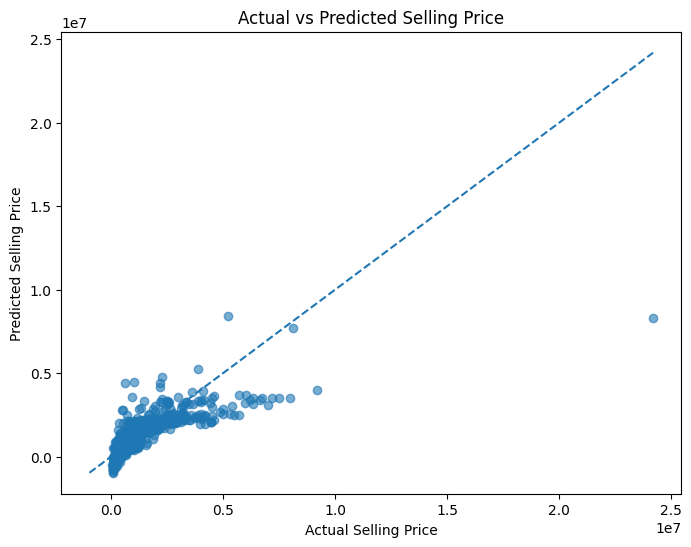

In [ ]:
# TASK 19 - Graph 1
# Actual vs Predicted Selling Price

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Selling Price')

plt.show()

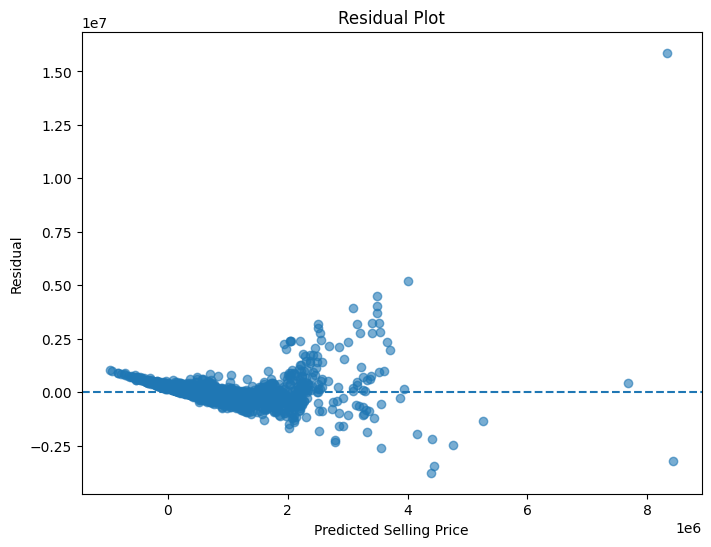

In [ ]:
# TASK 19 - Graph 2
# Residual Plot

residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted Selling Price')
plt.ylabel('Residual')
plt.title('Residual Plot')

plt.show()

### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


Conclusion

The Multiple Linear Regression model was successfully implemented using the Ordinary Least Squares (OLS) method. The model uses several vehicle-related features to predict the selling price of used cars.

Most influential features:
The features with larger absolute regression coefficients have a greater influence on the predicted selling price. In this experiment, features such as present vehicle characteristics, engine-related attributes, vehicle age, and kilometres driven can have a significant effect on selling price. Positive coefficients indicate that an increase in the corresponding feature tends to increase the predicted selling price, while negative coefficients indicate a decrease, keeping other features constant.

Advantages:

Simple and easy to understand.
Provides interpretable regression coefficients.
Can use multiple features simultaneously.
Computationally efficient for a moderate-sized dataset.
Helps identify which features have greater influence on car prices.

Limitations:

Assumes a linear relationship between the features and selling price.
Sensitive to outliers.
Multicollinearity between features can affect the regression coefficients.
Used-car prices can have complex and non-linear relationships that Multiple Linear Regression may not capture.
Prediction accuracy depends on the quality and relevance of the selected features.

Overall, Multiple Linear Regression provides a simple and interpretable approach for used-car price prediction, but more advanced models may be required to capture complex relationships in the data.

This matches the notebook's required conclusion points: comment on influential features and discuss the advantages and limitations of Multiple Linear Regression for used-car price prediction.